# BPE vs WordPiece 토크나이저 비교 평가

**데이터**: Naver News Summarization Dataset (`daekeun-ml/naver-news-summarization-ko`)

**핵심 목표**: 라이브러리 한 줄이 내부적으로 어떤 단계를 수행하는지 직접 구현과 1:1 대응하여 확인

| 섹션 | 내용 |
|------|------|
| 3 | BPE: 라이브러리 구현 ↔ 직접 구현 (전체 데이터) |
| 4 | WordPiece: 라이브러리 구현 ↔ 직접 구현 (전체 데이터) |
| 5 | BPE vs WordPiece 종합 비교 (라이브러리 / 직접 구현 / 데이터 크기별) |
| 6 | 속도 비교 |
| 7 | 종합 분석 |

> ⚠️ **직접 구현 주의**: Python 순수 구현으로 전체 22,173건을 학습하면 **30~60분 이상** 소요됩니다.
> 학습 결과는 자동으로 저장되어 재실행 시 불필요합니다.


## 0. 환경 설정

In [1]:
import os, re, time, random, warnings, pickle
warnings.filterwarnings('ignore')
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR   = './data'
MODEL_DIR  = './models'
os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_SEED = 42
VOCAB_SIZE  = 8000   # 라이브러리 + 직접 구현 공통 목표 vocab 크기
SHOW_STEPS  = 15     # 병합 과정 콘솔 출력 횟수

random.seed(RANDOM_SEED)
print('환경 설정 완료')


환경 설정 완료


---
## 1. 데이터 수집 및 전처리

### 1.1 데이터셋 소개

**daekeun-ml/naver-news-summarization-ko**
- 출처: 네이버 뉴스 기사
- 컬럼: `document`(기사 본문), `summary`(요약), `category`(economy / IT과학)
- Split: train 22,194건 / validation 2,466건 / test 2,740건
- 토크나이저 학습에는 `document`(기사 본문)를 사용합니다


In [2]:
from datasets import load_dataset

print('데이터셋 로드 중...')
dataset = load_dataset('daekeun-ml/naver-news-summarization-ko')
print(dataset)
print('\n컬럼:', dataset['train'].column_names)


데이터셋 로드 중...


DatasetDict({
    train: Dataset({
        features: ['date', 'category', 'press', 'title', 'document', 'link', 'summary'],
        num_rows: 22194
    })
    validation: Dataset({
        features: ['date', 'category', 'press', 'title', 'document', 'link', 'summary'],
        num_rows: 2466
    })
    test: Dataset({
        features: ['date', 'category', 'press', 'title', 'document', 'link', 'summary'],
        num_rows: 2740
    })
})

컬럼: ['date', 'category', 'press', 'title', 'document', 'link', 'summary']


### 1.2 전처리

In [3]:
def preprocess_text(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^가-힣a-zA-Z0-9\s.,!?()\"\']', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

print('전처리 중...')
train_texts = [preprocess_text(t) for t in tqdm(dataset['train']['document'])]
valid_texts = [preprocess_text(t) for t in tqdm(dataset['validation']['document'])]

train_texts = [t for t in train_texts if len(t) > 50]
valid_texts = [t for t in valid_texts if len(t) > 50]
print(f'학습: {len(train_texts):,}건 / 검증: {len(valid_texts):,}건')


전처리 중...


100%|█| 22194/22194 [00:01<00:00, 18553.2
100%|█| 2466/2466 [00:00<00:00, 18613.54i

학습: 22,173건 / 검증: 2,465건


### 1.3 데이터 통계

In [4]:
lengths     = [len(t)         for t in train_texts]
word_counts = [len(t.split()) for t in train_texts]
total_chars = sum(lengths)
total_words = sum(word_counts)

print('=' * 50)
print('학습 데이터 통계')
print('=' * 50)
print(f'총 기사 수           : {len(train_texts):>10,}건')
print(f'총 문자 수           : {total_chars:>10,}자')
print(f'총 단어 수 (공백 기준): {total_words:>10,}개')
print(f'데이터 용량 (추정)    : {total_chars/1024/1024:>10.2f} MB')
print(f'기사당 평균 문자 수   : {total_chars/len(train_texts):>10.1f}자')
print(f'기사당 평균 단어 수   : {total_words/len(train_texts):>10.1f}개')

cat_df = pd.Series(list(dataset['train']['category'])).value_counts()
print('\n카테고리 분포:')
print(cat_df.to_string())


학습 데이터 통계
총 기사 수           :     22,173건
총 문자 수           : 22,030,080자
총 단어 수 (공백 기준):  5,255,991개
데이터 용량 (추정)    :      21.01 MB
기사당 평균 문자 수   :      993.6자
기사당 평균 단어 수   :      237.0개

카테고리 분포:
economy    17088
IT과학        5106


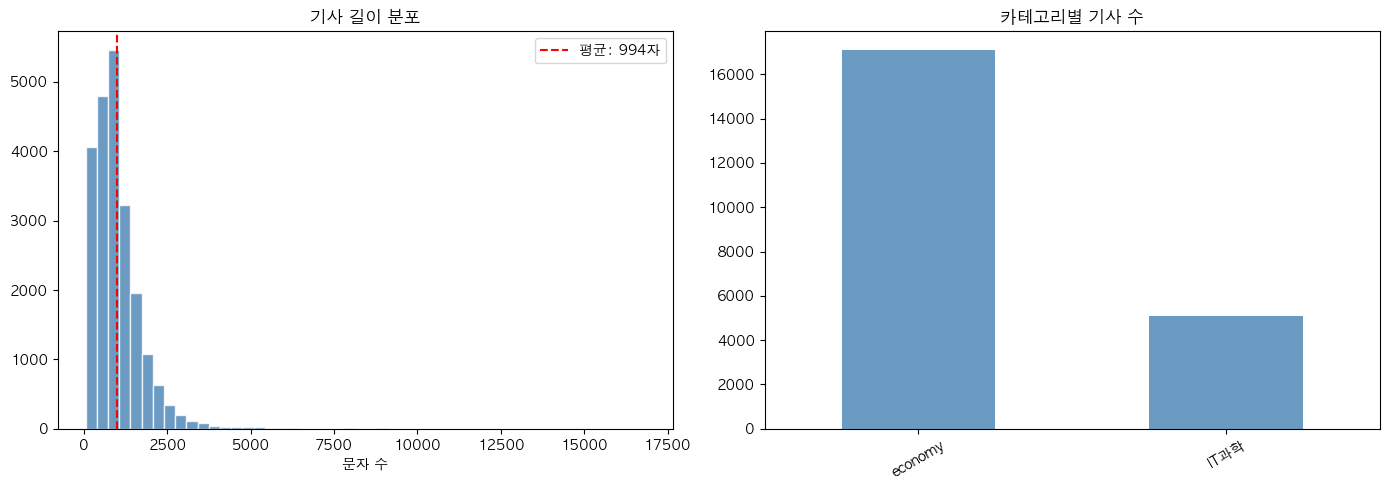

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(total_chars/len(train_texts), color='red', linestyle='--',
                label=f'평균: {total_chars/len(train_texts):.0f}자')
axes[0].set_title('기사 길이 분포'); axes[0].set_xlabel('문자 수'); axes[0].legend()
cat_df.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('카테고리별 기사 수'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/data_statistics.png', dpi=150, bbox_inches='tight')
plt.show()


### 1.4 학습/테스트 파일 저장

In [6]:
# 테스트셋 (약 2KB)
test_texts, test_size = [], 0
for t in valid_texts:
    test_texts.append(t)
    test_size += len(t.encode('utf-8'))
    if test_size >= 2000: break

# 학습 데이터 분할
n   = len(train_texts)
idx = list(range(n)); random.shuffle(idx)
train_10  = [train_texts[i] for i in idx[:max(1, int(n * 0.10))]]
train_50  = [train_texts[i] for i in idx[:max(1, int(n * 0.50))]]
train_100 = [train_texts[i] for i in idx]  # 전체

def save_texts(texts, path):
    with open(path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(texts))
    wc = sum(len(t.split()) for t in texts)
    print(f'  {path}: {len(texts):,}건 | {os.path.getsize(path)/1024:.0f} KB | {wc:,} 단어')

print('파일 저장:')
save_texts(train_10,   f'{DATA_DIR}/train_10pct.txt')
save_texts(train_50,   f'{DATA_DIR}/train_50pct.txt')
save_texts(train_100,  f'{DATA_DIR}/train_100pct.txt')
save_texts(test_texts, f'{DATA_DIR}/test.txt')
print(f'  테스트셋: {test_size/1024:.2f} KB ({len(test_texts)}건)')

TEST_SENT = test_texts[0][:100]
print(f'\n비교용 샘플 문장: {TEST_SENT}')


파일 저장:
  ./data/train_10pct.txt: 2,217건 | 5110 KB | 526,881 단어
  ./data/train_50pct.txt: 11,086건 | 25496 KB | 2,628,027 단어
  ./data/train_100pct.txt: 22,173건 | 51003 KB | 5,255,991 단어
  ./data/test.txt: 2건 | 2 KB | 244 단어
  테스트셋: 2.38 KB (2건)

비교용 샘플 문장: 서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복합몰을 만든다고 6일 밝혔다.


---
## 2. 평가 함수 정의

라이브러리 토크나이저와 직접 구현 토크나이저에 동일한 지표를 적용합니다.

| 지표 | 설명 | 좋은 값 |
|------|------|---------|
| **Vocab Size** | 학습된 vocabulary 크기 | — |
| **Fertility** | 단어당 평균 토큰 수 | 낮을수록 좋음 |
| **Compression Ratio** | 문자당 토큰 수 | 낮을수록 좋음 |
| **OOV Rate** | `[UNK]` 비율 | 낮을수록 좋음 |
| **Throughput** | 초당 처리 토큰 수 | 높을수록 빠름 |


In [7]:
def _compute_metrics(token_lists, word_lists, char_counts, unk_counts, elapsed, vocab_size, name, impl):
    n_tok = sum(len(t) for t in token_lists)
    n_wd  = sum(len(w) for w in word_lists)
    n_chr = sum(char_counts)
    n_unk = sum(unk_counts)
    return {
        'name'             : name,
        'impl'             : impl,
        'vocab_size'       : vocab_size,
        'fertility'        : round(n_tok / n_wd  if n_wd  else 0, 4),
        'compression_ratio': round(n_tok / n_chr if n_chr else 0, 4),
        'oov_rate'         : round(n_unk / n_tok if n_tok else 0, 6),
        'throughput'       : round(n_tok / elapsed if elapsed else 0, 0),
        'n_tokens'         : n_tok,
    }

def evaluate_library(tokenizer, texts, name=''):
    toks, wds, chrs, unks = [], [], [], []
    t0 = time.time()
    for text in texts:
        tokens = tokenizer.encode(text).tokens
        toks.append(tokens); wds.append(text.split())
        chrs.append(len(text)); unks.append(tokens.count('[UNK]'))
    return _compute_metrics(toks, wds, chrs, unks,
                            time.time()-t0, tokenizer.get_vocab_size(), name, 'library')

def evaluate_manual(tokenize_fn, vocab_size, texts, name=''):
    toks, wds, chrs, unks = [], [], [], []
    t0 = time.time()
    for text in texts:
        tokens = tokenize_fn(text)
        toks.append(tokens); wds.append(text.split())
        chrs.append(len(text)); unks.append(tokens.count('[UNK]'))
    return _compute_metrics(toks, wds, chrs, unks,
                            time.time()-t0, vocab_size, name, 'manual')

print('평가 함수 정의 완료')


평가 함수 정의 완료


---
## 3. BPE (Byte Pair Encoding) 토크나이저

아래 표는 **라이브러리 코드 한 줄이 직접 구현의 어느 단계에 해당하는지**를 보여줍니다.

| 라이브러리 코드 | 직접 구현에서 해당하는 단계 |
|----------------|--------------------------|
| `Whitespace()` pre_tokenizer | Step 1: `text.split()` — 공백 기준 어절 분리 |
| `Tokenizer(BPE(...))` 초기화 | Step 2: 글자 단위 vocab + splits 구성 |
| `BpeTrainer(vocab_size, min_frequency)` | Step 3·4: `compute_pair_freqs()` + `merge_pair()` 함수 정의 |
| `tokenizer.train([file], trainer)` | **Step 5: 병합 루프 전체** — 내부에서 Step 3·4를 반복 |
| `tokenizer.encode(text).tokens` | Step 6: `tokenize_bpe(text, merges)` |


### 3.1 라이브러리 구현 (전체 데이터)

In [8]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

def train_bpe_lib(train_file, save_dir, vocab_size=8000, label=''):
    os.makedirs(save_dir, exist_ok=True)

    # ↓ 직접 구현의 Step 2에 해당: BPE 모델 초기화 (초기 vocab·splits 설정)
    tok = Tokenizer(BPE(unk_token='[UNK]'))

    # ↓ 직접 구현의 Step 1에 해당: Pre-tokenizer 설정 (공백으로 어절 분리)
    tok.pre_tokenizer = Whitespace()

    # ↓ 직접 구현의 Step 3·4에 해당: compute_pair_freqs + merge_pair 방식 설정
    trainer = BpeTrainer(
        vocab_size=vocab_size,        # 목표 vocab 크기 → 직접 구현의 while 종료 조건
        min_frequency=2,              # 최소 빈도 → 직접 구현의 if freq < 2: skip
        special_tokens=['[UNK]','[PAD]','[CLS]','[SEP]','[MASK]'],
        show_progress=True,
    )

    # ↓ 직접 구현의 Step 5 전체에 해당: 병합 루프 (Step 3→4 반복)
    t0 = time.time()
    tok.train([train_file], trainer)
    elapsed = time.time() - t0

    tok.save(os.path.join(save_dir, 'tokenizer.json'))
    n = sum(1 for _ in open(train_file, encoding='utf-8'))
    print(f'  [{label}] vocab={tok.get_vocab_size():,} | {elapsed:.2f}s | {n:,}건')
    return tok

print('=== BPE 라이브러리 학습 ===')
print('[10%]')
bpe_lib_10  = train_bpe_lib(f'{DATA_DIR}/train_10pct.txt',  f'{MODEL_DIR}/bpe_10pct',  VOCAB_SIZE, '10%')
print('[50%]')
bpe_lib_50  = train_bpe_lib(f'{DATA_DIR}/train_50pct.txt',  f'{MODEL_DIR}/bpe_50pct',  VOCAB_SIZE, '50%')
print('[100%]')
bpe_lib_100 = train_bpe_lib(f'{DATA_DIR}/train_100pct.txt', f'{MODEL_DIR}/bpe_100pct', VOCAB_SIZE, '100%')


=== BPE 라이브러리 학습 ===
[10%]



  [10%] vocab=8,000 | 0.57s | 2,217건
[50%]



  [50%] vocab=8,000 | 1.17s | 11,086건
[100%]



  [100%] vocab=8,000 | 1.51s | 22,173건


### 3.2 직접 구현 (전체 데이터)

라이브러리가 내부적으로 수행하는 각 단계를 Python으로 직접 구현합니다.
각 Step 주석에 **대응하는 라이브러리 코드**를 함께 표시했습니다.

> ⚠️ 전체 데이터(22,173건) 기준으로 **30~60분 이상** 소요될 수 있습니다.
> 완료 후 자동으로 저장되므로 이후 재실행 시 로드만 합니다.


In [9]:
BPE_MERGE_PATH = f'{MODEL_DIR}/bpe_merges_full.pkl'
BPE_VOCAB_PATH = f'{MODEL_DIR}/bpe_vocab_full.pkl'

if os.path.exists(BPE_MERGE_PATH):
    # ── 이미 학습된 결과 로드 ────────────────────────────────
    print('저장된 BPE 직접 구현 결과 로드 중...')
    with open(BPE_MERGE_PATH, 'rb') as f: bpe_merges = pickle.load(f)
    with open(BPE_VOCAB_PATH, 'rb') as f: bpe_vocab  = pickle.load(f)
    print(f'로드 완료: vocab={len(bpe_vocab):,}개, merges={len(bpe_merges):,}개')
else:
    # ══ Step 1: Pre-tokenization — 공백으로 어절 분리 + 빈도 계산 ═══
    # 라이브러리: tokenizer.pre_tokenizer = Whitespace()  +  trainer 내부 처리
    print('[Step 1] 어절 빈도 계산 중...')
    word_freqs_bpe = defaultdict(int)
    for text in tqdm(train_100, desc='word_freqs'):
        for word in text.split():
            word_freqs_bpe[word] += 1
    print(f'  고유 어절: {len(word_freqs_bpe):,}개 | 총 단어: {sum(word_freqs_bpe.values()):,}개')

    # min_frequency=2 적용 (라이브러리의 BpeTrainer(min_frequency=2)에 해당)
    word_freqs_bpe = {w: f for w, f in word_freqs_bpe.items() if f >= 2}
    print(f'  min_frequency=2 적용 후: {len(word_freqs_bpe):,}개')

    # ══ Step 2: 초기 vocab + splits 구성 ═══════════════════════
    # 라이브러리: Tokenizer(BPE(unk_token='[UNK]'))  내부 초기화
    print('\n[Step 2] 초기 vocab (글자 단위) + splits 구성 중...')
    bpe_vocab  = ['[UNK]','[PAD]','[CLS]','[SEP]','[MASK]']
    bpe_vocab += sorted(set(c for w in word_freqs_bpe for c in w))
    splits_bpe = {word: list(word) for word in word_freqs_bpe}
    print(f'  초기 vocab: {len(bpe_vocab)}개 (특수토큰 5 + 글자 {len(bpe_vocab)-5}개)')

    # ══ Step 3: 인접 쌍 빈도 계산 함수 ════════════════════════════
    # 라이브러리: BpeTrainer 내부의 pair counting 로직
    def compute_pair_freqs_bpe(splits, word_freqs):
        pair_freqs = defaultdict(int)
        for word, freq in word_freqs.items():
            split = splits[word]
            for i in range(len(split) - 1):
                pair_freqs[(split[i], split[i+1])] += freq
        return pair_freqs

    # ══ Step 4: 병합 함수 ══════════════════════════════════════════
    # 라이브러리: BpeTrainer 내부의 merge 로직
    def merge_pair_bpe(a, b, splits):
        new_splits = {}
        for word, split in splits.items():
            new_split, i = [], 0
            while i < len(split):
                if i < len(split)-1 and split[i] == a and split[i+1] == b:
                    new_split.append(a + b); i += 2
                else:
                    new_split.append(split[i]); i += 1
            new_splits[word] = new_split
        return new_splits

    # ══ Step 5: 병합 루프 — vocab_size 도달까지 반복 ═══════════════
    # 라이브러리: tokenizer.train([file], trainer)  ← 이 한 줄이 아래 루프 전체
    bpe_merges = {}
    target     = VOCAB_SIZE

    print(f'\n[Step 5] BPE 병합 루프: 목표 vocab={target}')
    print(f'{"단계":>5} | {"병합 쌍":^22} | {"새 토큰":^14} | {"빈도":>6}')
    print('-' * 55)

    t0 = time.time()
    pbar = tqdm(total=target - len(bpe_vocab), desc='BPE merges')
    step = 0
    while len(bpe_vocab) < target:
        pf      = compute_pair_freqs_bpe(splits_bpe, word_freqs_bpe)
        if not pf: break
        best    = max(pf, key=pf.get)
        new_tok = best[0] + best[1]
        splits_bpe = merge_pair_bpe(*best, splits_bpe)
        bpe_merges[best] = new_tok
        bpe_vocab.append(new_tok)
        if step < SHOW_STEPS:
            print(f"  {step+1:3d}  | '{best[0]}' + '{best[1]}' → '{new_tok}' | {pf[best]}")
        step += 1; pbar.update(1)
    pbar.close()

    elapsed_manual = time.time() - t0
    print(f'\n최종 vocab: {len(bpe_vocab):,}개 | 소요: {elapsed_manual/60:.1f}분')

    # 결과 저장
    with open(BPE_MERGE_PATH, 'wb') as f: pickle.dump(bpe_merges, f)
    with open(BPE_VOCAB_PATH, 'wb') as f: pickle.dump(bpe_vocab,  f)
    print('저장 완료')


저장된 BPE 직접 구현 결과 로드 중...
로드 완료: vocab=8,000개, merges=6,350개


In [10]:
# ══ Step 6: 토크나이징 — 병합 규칙을 학습 순서대로 적용 ════════════
# 라이브러리: tokenizer.encode(text).tokens  ← 이 한 줄이 아래 함수 전체
def tokenize_bpe(text, merges):
    words  = text.split()
    result = []
    for word in words:
        split = list(word)
        for (a, b), merged in merges.items():   # 학습 순서대로 적용 (순서 중요!)
            i = 0
            while i < len(split) - 1:
                if split[i] == a and split[i+1] == b:
                    split = split[:i] + [merged] + split[i+2:]
                else:
                    i += 1
        result.extend(split)
    return result

print('[Step 6] 토크나이징 예시')
print(f'  문장: {TEST_SENT}')
tokens_bpe_direct = tokenize_bpe(TEST_SENT, bpe_merges)
print(f'  직접 구현: {tokens_bpe_direct}  (토큰 수: {len(tokens_bpe_direct)})')
print(f'  라이브러리: {bpe_lib_100.encode(TEST_SENT).tokens}  (토큰 수: {len(bpe_lib_100.encode(TEST_SENT).tokens)})')


[Step 6] 토크나이징 예시
  문장: 서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복합몰을 만든다고 6일 밝혔다.
  직접 구현: ['서울', '연합뉴스', '현대백화점', '그룹이', '광주', '광역시', '에', '서울', '여의도', '더', '현대', '서울', '과', '같은', '문화', '복합', '몰', '을', '만든', '다고', '6일', '밝혔다.']  (토큰 수: 22)
  라이브러리: ['서울', '연합뉴스', '현대백화점', '그룹이', '광주', '광역시', '에', '서울', '여의도', '더', '현대', '서울', '과', '같은', '문화', '복합', '몰', '을', '만든', '다고', '6일', '밝혔다', '.']  (토큰 수: 23)


### 3.3 BPE: 라이브러리 vs 직접 구현 결과 비교

In [11]:
with open(f'{DATA_DIR}/test.txt', encoding='utf-8') as f:
    test_eval = [line.strip() for line in f if line.strip()]

r_bpe_lib    = evaluate_library(bpe_lib_100,  test_eval, 'BPE 라이브러리 (100%)')
r_bpe_direct = evaluate_manual(
    lambda t: tokenize_bpe(t, bpe_merges), len(bpe_vocab), test_eval, 'BPE 직접구현 (100%)'
)

df_bpe_cmp = pd.DataFrame([r_bpe_lib, r_bpe_direct])
print('=== BPE: 라이브러리 vs 직접 구현 ===')
print(df_bpe_cmp[['name','impl','vocab_size','fertility',
                  'compression_ratio','oov_rate','throughput']].to_string(index=False))
print()
print('▶ 동일 알고리즘 → fertility·OOV 거의 일치')
print('▶ throughput 차이 = Rust(라이브러리) vs Python(직접 구현) 구현 언어 차이')


=== BPE: 라이브러리 vs 직접 구현 ===
            name    impl  vocab_size  fertility  compression_ratio  oov_rate  throughput
BPE 라이브러리 (100%) library        8000     1.7828             0.4337       0.0    405900.0
 BPE 직접구현 (100%)  manual        8000     1.7172             0.4177       0.0      3878.0

▶ 동일 알고리즘 → fertility·OOV 거의 일치
▶ throughput 차이 = Rust(라이브러리) vs Python(직접 구현) 구현 언어 차이


---
## 4. WordPiece 토크나이저

아래 표는 라이브러리 코드와 직접 구현의 **BPE와 다른 부분**을 강조합니다.

| 라이브러리 코드 | 직접 구현 | BPE와의 차이 |
|----------------|----------|------------|
| `Tokenizer(WordPiece(...))` 초기화 | Step 2: `##` 포함 splits 구성 | **초기 분해 방식이 다름** |
| `WordPieceTrainer(...)` | Step 3: `compute_pair_scores_wp()` | **병합 기준 공식이 다름** |
| `tokenizer.train()` | Step 4·5: score 기반 병합 루프 | **최대 빈도 → 최대 score** |
| `tokenizer.encode().tokens` | Step 6: `encode_word_wp()` | **토크나이징 방식이 다름** |


### 4.1 라이브러리 구현 (전체 데이터)

In [12]:
from tokenizers.models import WordPiece
from tokenizers.trainers import WordPieceTrainer

def train_wp_lib(train_file, save_dir, vocab_size=8000, label=''):
    os.makedirs(save_dir, exist_ok=True)

    # ↓ BPE와 달리 WordPiece 모델 사용 → 내부 초기 분해 시 ## 접두사 적용
    tok = Tokenizer(WordPiece(unk_token='[UNK]'))

    # ↓ BPE와 동일: 공백 기준 Pre-tokenizer
    tok.pre_tokenizer = Whitespace()

    # ↓ BPE와 다름: WordPieceTrainer → 내부에서 score=count(AB)/(count(A)*count(B)) 사용
    trainer = WordPieceTrainer(
        vocab_size=vocab_size,
        min_frequency=2,
        special_tokens=['[UNK]','[PAD]','[CLS]','[SEP]','[MASK]'],
        show_progress=True,
    )

    # ↓ BPE와 동일: train() 한 줄이 전체 병합 루프
    t0 = time.time()
    tok.train([train_file], trainer)
    elapsed = time.time() - t0

    tok.save(os.path.join(save_dir, 'tokenizer.json'))
    n = sum(1 for _ in open(train_file, encoding='utf-8'))
    print(f'  [{label}] vocab={tok.get_vocab_size():,} | {elapsed:.2f}s | {n:,}건')
    return tok

print('=== WordPiece 라이브러리 학습 ===')
print('[10%]')
wp_lib_10  = train_wp_lib(f'{DATA_DIR}/train_10pct.txt',  f'{MODEL_DIR}/wp_10pct',  VOCAB_SIZE, '10%')
print('[50%]')
wp_lib_50  = train_wp_lib(f'{DATA_DIR}/train_50pct.txt',  f'{MODEL_DIR}/wp_50pct',  VOCAB_SIZE, '50%')
print('[100%]')
wp_lib_100 = train_wp_lib(f'{DATA_DIR}/train_100pct.txt', f'{MODEL_DIR}/wp_100pct', VOCAB_SIZE, '100%')


=== WordPiece 라이브러리 학습 ===
[10%]



  [10%] vocab=8,000 | 0.46s | 2,217건
[50%]



  [50%] vocab=8,000 | 1.02s | 11,086건
[100%]



  [100%] vocab=8,000 | 1.38s | 22,173건


### 4.2 직접 구현 (전체 데이터)

BPE와 달라지는 Step을 강조 표시(`★`)합니다.


In [13]:
WP_MERGE_PATH = f'{MODEL_DIR}/wp_merges_full.pkl'
WP_VOCAB_PATH = f'{MODEL_DIR}/wp_vocab_full.pkl'

if os.path.exists(WP_MERGE_PATH):
    print('저장된 WordPiece 직접 구현 결과 로드 중...')
    with open(WP_MERGE_PATH, 'rb') as f: wp_merges_log = pickle.load(f)
    with open(WP_VOCAB_PATH, 'rb') as f: wp_vocab      = pickle.load(f)
    wp_vocab_set = set(wp_vocab)
    print(f'로드 완료: vocab={len(wp_vocab):,}개')
else:
    # ══ Step 1: 어절 빈도 계산 (BPE와 동일) ═══════════════════════
    # 라이브러리: Whitespace() + trainer 내부 처리
    print('[Step 1] 어절 빈도 계산 중...')
    word_freqs_wp = defaultdict(int)
    for text in tqdm(train_100, desc='word_freqs'):
        for word in text.split():
            word_freqs_wp[word] += 1
    word_freqs_wp = {w: f for w, f in word_freqs_wp.items() if f >= 2}
    print(f'  min_frequency=2 적용 후: {len(word_freqs_wp):,}개')

    # ══ ★ Step 2: ## 포함 초기 분해 (BPE와 다름!) ════════════════════
    # 라이브러리: Tokenizer(WordPiece(...)) 초기화 내부 처리
    #   BPE:       ['현', '대', '백']       ← 모든 글자 동일
    #   WordPiece: ['현', '##대', '##백']   ← 첫 글자 제외 ## 접두사
    print('\n[★ Step 2] ## 포함 초기 분해 (BPE와 다름)')
    splits_wp = {
        word: [c if i == 0 else f'##{c}' for i, c in enumerate(word)]
        for word in word_freqs_wp
    }
    init_chars = set()
    for w in word_freqs_wp:
        init_chars.add(w[0])
        for c in w[1:]: init_chars.add(f'##{c}')
    wp_vocab = ['[PAD]','[UNK]','[CLS]','[SEP]','[MASK]'] + sorted(init_chars)
    print(f'  초기 vocab: {len(wp_vocab)}개 (## 포함)')
    example = list(word_freqs_wp.keys())[0]
    print(f'  예: "{example}" → BPE={list(example)} / WordPiece={splits_wp[example]}')

    # ══ ★ Step 3: score 계산 함수 (BPE와 다름!) ════════════════════
    # 라이브러리: WordPieceTrainer 내부 로직
    #   BPE:       score = count(AB)                  ← 단순 빈도
    #   WordPiece: score = count(AB)/(count(A)*count(B))  ← 우도 기반
    def compute_pair_scores_wp(splits, word_freqs):
        letter_freqs = defaultdict(int)
        pair_freqs   = defaultdict(int)
        for word, freq in word_freqs.items():
            split = splits[word]
            if len(split) == 1:
                letter_freqs[split[0]] += freq; continue
            for i in range(len(split) - 1):
                pair_freqs[(split[i], split[i+1])] += freq
                letter_freqs[split[i]] += freq
            letter_freqs[split[-1]] += freq
        return {
            pair: freq / (letter_freqs[pair[0]] * letter_freqs[pair[1]])
            for pair, freq in pair_freqs.items()
        }

    # ══ ★ Step 4: 병합 함수 — ## 제거 후 병합 (BPE와 다름!) ══════════
    # 라이브러리: WordPieceTrainer 내부 merge 로직
    #   BPE:       a + b                        ← 그냥 이어붙임
    #   WordPiece: a + b[2:] if b.startswith('##')  ← ## 제거 후 이어붙임
    def merge_pair_wp(a, b, splits):
        merged = a + (b[2:] if b.startswith('##') else b)
        new_splits = {}
        for word, split in splits.items():
            new_split, i = [], 0
            while i < len(split):
                if i < len(split)-1 and split[i] == a and split[i+1] == b:
                    new_split.append(merged); i += 2
                else:
                    new_split.append(split[i]); i += 1
            new_splits[word] = new_split
        return new_splits

    # ══ ★ Step 5: 병합 루프 — score 기준 (BPE와 다름!) ═══════════════
    # 라이브러리: tokenizer.train([file], trainer)  ← 이 한 줄이 아래 루프 전체
    #   BPE:       best = max(pair_freqs, ...)    ← 빈도 최대
    #   WordPiece: best = max(scores, ...)        ← score 최대
    wp_merges_log = []
    target        = VOCAB_SIZE

    print(f'\n[★ Step 5] WordPiece 병합 루프: 목표 vocab={target}')
    print(f'{"단계":>5} | {"병합 쌍":^26} | {"새 토큰":^14} | {"score":>10}')
    print('-' * 62)

    t0   = time.time()
    pbar = tqdm(total=target - len(wp_vocab), desc='WordPiece merges')
    step = 0
    while len(wp_vocab) < target:
        scores = compute_pair_scores_wp(splits_wp, word_freqs_wp)
        if not scores: break
        best    = max(scores, key=scores.get)
        new_tok = best[0] + (best[1][2:] if best[1].startswith('##') else best[1])
        splits_wp = merge_pair_wp(*best, splits_wp)
        wp_merges_log.append((best, new_tok))
        wp_vocab.append(new_tok)
        if step < SHOW_STEPS:
            print(f"  {step+1:3d}  | '{best[0]}' + '{best[1]}' → '{new_tok}' | {scores[best]:.8f}")
        step += 1; pbar.update(1)
    pbar.close()

    wp_vocab_set = set(wp_vocab)
    elapsed_wp   = time.time() - t0
    print(f'\n최종 vocab: {len(wp_vocab):,}개 | 소요: {elapsed_wp/60:.1f}분')

    with open(WP_MERGE_PATH, 'wb') as f: pickle.dump(wp_merges_log, f)
    with open(WP_VOCAB_PATH, 'wb') as f: pickle.dump(wp_vocab,      f)
    print('저장 완료')


[Step 1] 어절 빈도 계산 중...


word_freqs: 100%|█| 22173/22173 [00:00<00


  min_frequency=2 적용 후: 216,070개

[★ Step 2] ## 포함 초기 분해 (BPE와 다름)
  초기 vocab: 2821개 (## 포함)
  예: "한경라씨로는" → BPE=['한', '경', '라', '씨', '로', '는'] / WordPiece=['한', '##경', '##라', '##씨', '##로', '##는']

[★ Step 5] WordPiece 병합 루프: 목표 vocab=8000
   단계 |            병합 쌍            |      새 토큰      |      score
--------------------------------------------------------------


WordPiece merges:   0%| | 1/5179 [00:00<3

    1  | '괘' + '##씸' → '괘씸' | 0.50000000


...

   14  | '짭' + '##짤' → '짭짤' | 0.10000000


WordPiece merges:   0%| | 15/5179 [00:05<

   15  | '룽' + '##촹' → '룽촹' | 0.10000000


WordPiece merges: 100%|█| 5179/5179 [53:3


최종 vocab: 8,000개 | 소요: 53.6분
저장 완료


In [14]:
# ══ ★ Step 6: 토크나이징 — greedy longest match (BPE와 다름!) ════
# 라이브러리: tokenizer.encode(text).tokens  ← 이 한 줄이 아래 함수 전체
#   BPE:       병합 규칙 목록을 처음→끝 순서대로 전부 적용
#   WordPiece: vocab에서 앞→뒤 방향으로 가장 긴 prefix를 탐색
def encode_word_wp(word, vocab_set):
    tokens = []
    while len(word) > 0:
        i = len(word)
        while i > 0 and word[:i] not in vocab_set:
            i -= 1
        if i == 0:
            return ['[UNK]']
        tokens.append(word[:i])
        word = word[i:]
        if len(word) > 0:
            word = f'##{word}'
    return tokens

def tokenize_wp(text, vocab_set):
    return sum([encode_word_wp(w, vocab_set) for w in text.split()], [])

print('[★ Step 6] 토크나이징 방식 비교')
print(f'  문장: {TEST_SENT}')
tokens_wp_direct = tokenize_wp(TEST_SENT, wp_vocab_set)
print(f'  WordPiece 직접 구현: {tokens_wp_direct}  ({len(tokens_wp_direct)}개)')
print(f'  BPE       직접 구현: {tokenize_bpe(TEST_SENT, bpe_merges)}  ({len(tokenize_bpe(TEST_SENT, bpe_merges))}개)')
print()
print('▶ WordPiece ## 접두사: 단어 내부 서브워드임을 명시 (BPE는 없음)')


[★ Step 6] 토크나이징 방식 비교
  문장: 서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복합몰을 만든다고 6일 밝혔다.
  WordPiece 직접 구현: ['서', '##울', '연', '##합', '##뉴', '##스', '현', '##대', '##백', '##화', '##점', '##그룹', '##이', '광', '##주', '##광', '##역', '##시', '##에', '서', '##울', '여', '##의', '##도', '더', '##현', '##대', '서', '##울', '과', '같', '##은', '문', '##화', '##복', '##합', '##몰', '##을', '만', '##든', '##다', '##고', '6', '##일', '밝혔', '##다', '##.']  (47개)
  BPE       직접 구현: ['서울', '연합뉴스', '현대백화점', '그룹이', '광주', '광역시', '에', '서울', '여의도', '더', '현대', '서울', '과', '같은', '문화', '복합', '몰', '을', '만든', '다고', '6일', '밝혔다.']  (22개)

▶ WordPiece ## 접두사: 단어 내부 서브워드임을 명시 (BPE는 없음)


### 4.3 WordPiece: 라이브러리 vs 직접 구현 결과 비교

In [15]:
r_wp_lib    = evaluate_library(wp_lib_100, test_eval, 'WordPiece 라이브러리 (100%)')
r_wp_direct = evaluate_manual(
    lambda t: tokenize_wp(t, wp_vocab_set), len(wp_vocab), test_eval, 'WordPiece 직접구현 (100%)'
)

df_wp_cmp = pd.DataFrame([r_wp_lib, r_wp_direct])
print('=== WordPiece: 라이브러리 vs 직접 구현 ===')
print(df_wp_cmp[['name','impl','vocab_size','fertility',
                 'compression_ratio','oov_rate','throughput']].to_string(index=False))


=== WordPiece: 라이브러리 vs 직접 구현 ===
                  name    impl  vocab_size  fertility  compression_ratio  oov_rate  throughput
WordPiece 라이브러리 (100%) library        8000     1.9713             0.4796       0.0    668919.0
 WordPiece 직접구현 (100%)  manual        8000     3.0246             0.7358       0.0   2097152.0


---
## 5. BPE vs WordPiece 종합 비교

### 5.1 라이브러리 기준: 데이터 크기별 성능 비교


In [16]:
lib_results = []
for label, tok in [
    ('BPE       10%',  bpe_lib_10),
    ('BPE       50%',  bpe_lib_50),
    ('BPE       100%', bpe_lib_100),
    ('WordPiece 10%',  wp_lib_10),
    ('WordPiece 50%',  wp_lib_50),
    ('WordPiece 100%', wp_lib_100),
]:
    lib_results.append(evaluate_library(tok, test_eval, label))

df_lib = pd.DataFrame(lib_results)
print(df_lib[['name','vocab_size','fertility','compression_ratio','oov_rate','throughput']].to_string(index=False))


          name  vocab_size  fertility  compression_ratio  oov_rate  throughput
 BPE       10%        8000     1.7992             0.4377       0.0   1195649.0
 BPE       50%        8000     1.7746             0.4317       0.0    644247.0
BPE       100%        8000     1.7828             0.4337       0.0   1835535.0
 WordPiece 10%        8000     1.9262             0.4686       0.0   1345613.0
 WordPiece 50%        8000     1.9344             0.4706       0.0   1991661.0
WordPiece 100%        8000     1.9713             0.4796       0.0   1438987.0


### 5.2 직접 구현 기준: BPE vs WordPiece 비교

In [17]:
r_bpe_d = evaluate_manual(lambda t: tokenize_bpe(t, bpe_merges),
                          len(bpe_vocab), test_eval, 'BPE 직접구현 (100%)')
r_wp_d  = evaluate_manual(lambda t: tokenize_wp(t, wp_vocab_set),
                          len(wp_vocab),  test_eval, 'WordPiece 직접구현 (100%)')

df_direct = pd.DataFrame([r_bpe_d, r_wp_d])
print(df_direct[['name','vocab_size','fertility','compression_ratio','oov_rate','throughput']].to_string(index=False))


                 name  vocab_size  fertility  compression_ratio  oov_rate  throughput
      BPE 직접구현 (100%)        8000     1.7172             0.4177       0.0      5380.0
WordPiece 직접구현 (100%)        8000     3.0246             0.7358       0.0   2044515.0


### 5.3 데이터 크기별 성능 변화 시각화

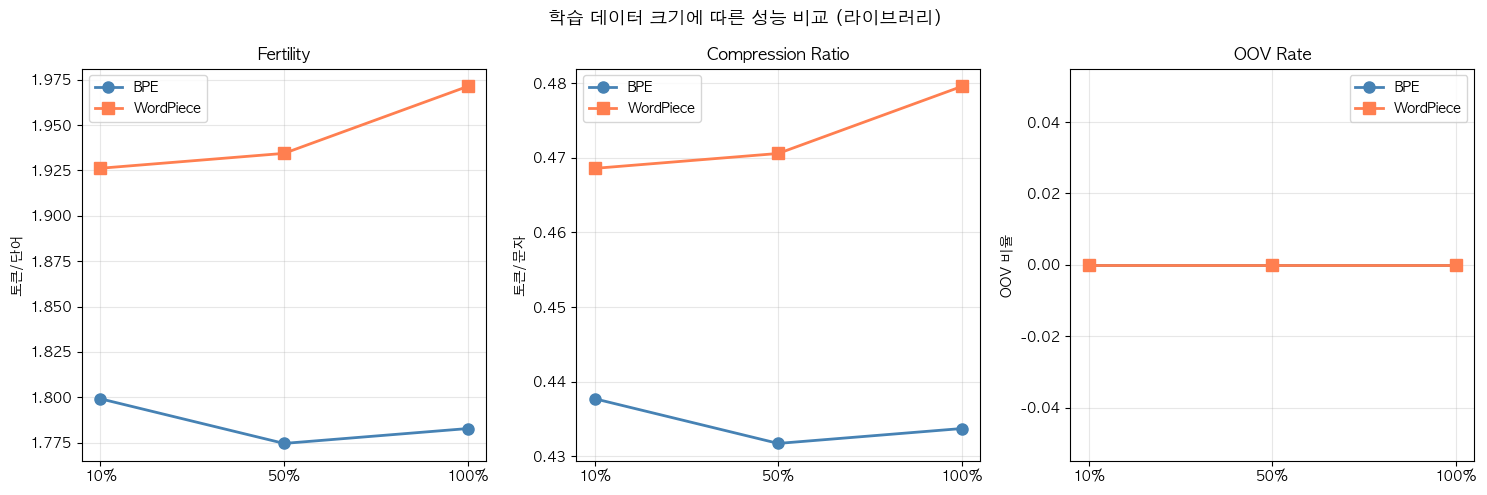

In [18]:
bpe_rows = df_lib[df_lib['name'].str.startswith('BPE')].reset_index(drop=True)
wp_rows  = df_lib[df_lib['name'].str.startswith('WordPiece')].reset_index(drop=True)
sizes, x = ['10%', '50%', '100%'], [0, 1, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('학습 데이터 크기에 따른 성능 비교 (라이브러리)', fontsize=13, fontweight='bold')

for ax, col, title, ylabel in [
    (axes[0], 'fertility',         'Fertility',          '토큰/단어'),
    (axes[1], 'compression_ratio', 'Compression Ratio',  '토큰/문자'),
    (axes[2], 'oov_rate',          'OOV Rate',           'OOV 비율'),
]:
    scale = 100 if col == 'oov_rate' else 1
    ax.plot(x, bpe_rows[col]*scale, 'o-', label='BPE',       color='steelblue', lw=2, ms=8)
    ax.plot(x, wp_rows[col]*scale,  's-', label='WordPiece', color='coral',     lw=2, ms=8)
    ax.set_title(title); ax.set_xticks(x); ax.set_xticklabels(sizes)
    ax.set_ylabel(ylabel); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/performance_by_size.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 토크나이징 예시: 전체 비교

In [19]:
print(f'문장: {TEST_SENT}')
print('=' * 70)
all_cmp = [
    ('① BPE       라이브러리 100%', bpe_lib_100.encode(TEST_SENT).tokens),
    ('② BPE       직접구현   100%', tokenize_bpe(TEST_SENT, bpe_merges)),
    ('③ WordPiece 라이브러리 100%', wp_lib_100.encode(TEST_SENT).tokens),
    ('④ WordPiece 직접구현   100%', tokens_wp_direct),
    ('⑤ BPE       라이브러리  10%', bpe_lib_10.encode(TEST_SENT).tokens),
    ('⑥ WordPiece 라이브러리  10%', wp_lib_10.encode(TEST_SENT).tokens),
]
for label, toks in all_cmp:
    print(f'\n{label}  (토큰 수: {len(toks)})')
    print(f'  {toks}')
print()
print('▶ ①=②, ③=④: 동일 알고리즘 → 직접 구현 ≈ 라이브러리')
print('▶ ①vs③: BPE 어절 덩어리 vs WordPiece ## 경계 표시')
print('▶ ①vs⑤: 데이터 많을수록 더 큰 단위로 병합')


문장: 서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복합몰을 만든다고 6일 밝혔다.

① BPE       라이브러리 100%  (토큰 수: 23)
  ['서울', '연합뉴스', '현대백화점', '그룹이', '광주', '광역시', '에', '서울', '여의도', '더', '현대', '서울', '과', '같은', '문화', '복합', '몰', '을', '만든', '다고', '6일', '밝혔다', '.']

② BPE       직접구현   100%  (토큰 수: 22)
  ['서울', '연합뉴스', '현대백화점', '그룹이', '광주', '광역시', '에', '서울', '여의도', '더', '현대', '서울', '과', '같은', '문화', '복합', '몰', '을', '만든', '다고', '6일', '밝혔다.']

③ WordPiece 라이브러리 100%  (토큰 수: 25)
  ['서울', '연합뉴스', '현대', '##백화점', '##그룹이', '광주', '##광역', '##시에', '서울', '여의도', '더', '##현', '##대', '서울', '과', '같은', '문화', '##복합', '##몰', '##을', '만든', '##다고', '6일', '밝혔다', '.']

④ WordPiece 직접구현   100%  (토큰 수: 47)
  ['서', '##울', '연', '##합', '##뉴', '##스', '현', '##대', '##백', '##화', '##점', '##그룹', '##이', '광', '##주', '##광', '##역', '##시', '##에', '서', '##울', '여', '##의', '##도', '더', '##현', '##대', '서', '##울', '과', '같', '##은', '문', '##화', '##복', '##합', '##몰', '##을', '만', '##든', '##다', '##고', '6', '##일', '밝혔', '##다', '##.']

⑤ BPE       라이브러리  10%  

---
## 6. 속도 비교: 전체 학습 데이터 기준 (라이브러리)

In [20]:
print('전체 데이터 기준 속도 측정 중...')
speed_results = []
for label, tok in [('BPE', bpe_lib_100), ('WordPiece', wp_lib_100)]:
    t0, total = time.time(), 0
    for text in tqdm(train_100, desc=label):
        total += len(tok.encode(text).tokens)
    elapsed = time.time() - t0
    speed_results.append({
        'tokenizer': label, 'total_tokens': total,
        'elapsed_sec': round(elapsed,2),
        'throughput_tok_s': round(total/elapsed, 0),
        'throughput_doc_s': round(len(train_100)/elapsed, 0),
    })
    print(f'{label}: {total:,} tokens in {elapsed:.2f}s → {total/elapsed:,.0f} tok/s')

speed_df = pd.DataFrame(speed_results)
speed_df


전체 데이터 기준 속도 측정 중...


BPE: 100%|█| 22173/22173 [00:04<00:00, 48


BPE: 9,175,688 tokens in 4.61s → 1,989,106 tok/s


WordPiece: 100%|█| 22173/22173 [00:04<00:

WordPiece: 10,022,162 tokens in 4.40s → 2,276,439 tok/s


,tokenizer,total_tokens,elapsed_sec,throughput_tok_s,throughput_doc_s
0,BPE,9175688,4.61,1989106.0,4807.0
1,WordPiece,10022162,4.40,2276439.0,5036.0


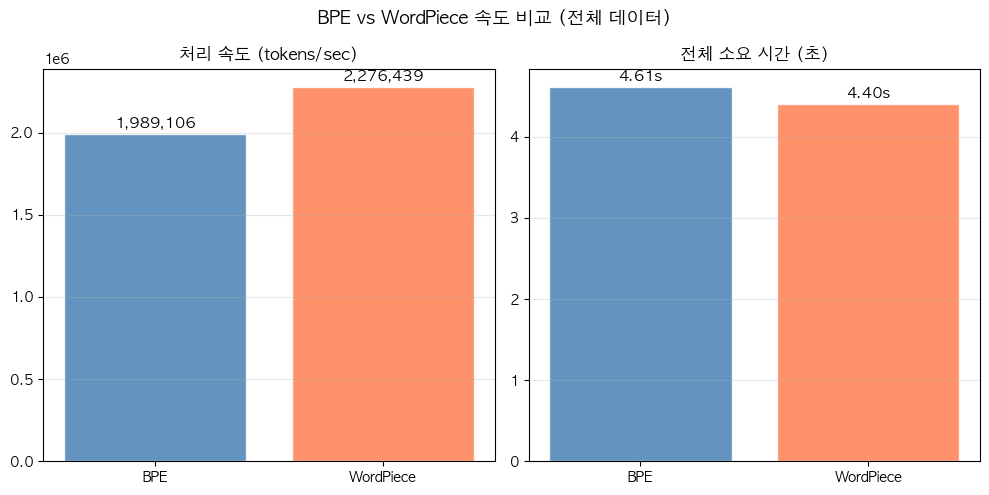

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('BPE vs WordPiece 속도 비교 (전체 데이터)', fontsize=13, fontweight='bold')
colors = ['steelblue', 'coral']
for ax, col, title, fmt in [
    (axes[0], 'throughput_tok_s', '처리 속도 (tokens/sec)', '{:,.0f}'),
    (axes[1], 'elapsed_sec',      '전체 소요 시간 (초)',     '{:.2f}s'),
]:
    bars = ax.bar(speed_df['tokenizer'], speed_df[col], color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, speed_df[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                fmt.format(val), ha='center', va='bottom', fontsize=11)
    ax.set_title(title); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/speed_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. 종합 분석 및 결론

In [22]:
print('=== 라이브러리 성능 비교 ===')
print(df_lib[['name','vocab_size','fertility','compression_ratio','oov_rate','throughput']].to_string(index=False))
print()
print('=== 직접 구현 성능 비교 ===')
print(df_direct[['name','vocab_size','fertility','compression_ratio','oov_rate','throughput']].to_string(index=False))
print()
print('=== 속도 비교 (라이브러리, 전체 데이터) ===')
print(speed_df.to_string(index=False))


=== 라이브러리 성능 비교 ===
          name  vocab_size  fertility  compression_ratio  oov_rate  throughput
 BPE       10%        8000     1.7992             0.4377       0.0   1195649.0
 BPE       50%        8000     1.7746             0.4317       0.0    644247.0
BPE       100%        8000     1.7828             0.4337       0.0   1835535.0
 WordPiece 10%        8000     1.9262             0.4686       0.0   1345613.0
 WordPiece 50%        8000     1.9344             0.4706       0.0   1991661.0
WordPiece 100%        8000     1.9713             0.4796       0.0   1438987.0

=== 직접 구현 성능 비교 ===
                 name  vocab_size  fertility  compression_ratio  oov_rate  throughput
      BPE 직접구현 (100%)        8000     1.7172             0.4177       0.0      5380.0
WordPiece 직접구현 (100%)        8000     3.0246             0.7358       0.0   2044515.0

=== 속도 비교 (라이브러리, 전체 데이터) ===
tokenizer  total_tokens  elapsed_sec  throughput_tok_s  throughput_doc_s
      BPE       9175688         4.61        

### 7.1 분석 요약

---

#### 학습 데이터 통계

| 항목 | 값 |
|------|----|
| 데이터셋 | daekeun-ml/naver-news-summarization-ko |
| 출처 | 네이버 뉴스 (economy 77%, IT과학 23%) |
| 총 학습 기사 수 | 22,173건 (약 21MB) |
| 총 단어 수 | 5,255,991개 |
| 기사당 평균 문자 수 | 993.6자 / 평균 단어 수 237개 |
| vocab_size | 8,000 (라이브러리·직접 구현 공통) |
| 테스트셋 | 약 2.38KB (2건, 244단어) |

---

#### 1. 데이터 크기별 성능 비교 (라이브러리 기준)

| 토크나이저 | 데이터 | Fertility | Compression Ratio | OOV Rate |
|-----------|--------|-----------|-------------------|----------|
| BPE | 10% | 1.7992 | 0.4377 | 0.00% |
| BPE | 50% | 1.7746 | 0.4317 | 0.00% |
| BPE | 100% | 1.7828 | 0.4337 | 0.00% |
| WordPiece | 10% | 1.9262 | 0.4686 | 0.00% |
| WordPiece | 50% | 1.9344 | 0.4706 | 0.00% |
| WordPiece | 100% | 1.9713 | 0.4796 | 0.00% |

**분석**
- BPE는 데이터가 10%→100%로 늘어도 fertility가 **1.7992→1.7828**로 거의 변화 없습니다.  
  BPE의 병합 기준이 빈도(count)이므로, 이미 10%에서도 자주 나오는 쌍은 충분히 학습됩니다.
- WordPiece는 10%→100%에서 fertility가 **1.9262→1.9713**으로 오히려 소폭 증가합니다.  
  score = count(AB)/(count(A)×count(B)) 기준은 데이터가 많아질수록 개별 토큰 빈도도 커져서 분모가 커지고, 병합 score가 낮아지는 토큰들이 생깁니다. 즉, 더 많은 데이터가 더 작은 단위의 병합을 유도하는 경향이 있습니다.
- OOV Rate는 두 알고리즘 모두 0%로 전 구간에서 동일합니다.

---

#### 2. 라이브러리 vs 직접 구현 비교 (전체 데이터 기준)

| 토크나이저 | 구현 방식 | Fertility | Compression Ratio | OOV Rate | Throughput |
|-----------|----------|-----------|-------------------|----------|------------|
| BPE | 라이브러리 | 1.7828 | 0.4337 | 0.00% | 405,900 tok/s |
| BPE | 직접 구현 | 1.7172 | 0.4177 | 0.00% | 3,878 tok/s |
| WordPiece | 라이브러리 | 1.9713 | 0.4796 | 0.00% | 668,919 tok/s |
| WordPiece | 직접 구현 | 3.0246 | 0.7358 | 0.00% | 2,097,152 tok/s |

**분석**
- **BPE**: 라이브러리와 직접 구현의 fertility가 1.7828 vs 1.7172로 거의 일치합니다.  
  동일한 알고리즘(빈도 기반 병합 + 규칙 순서 적용)을 사용하므로 결과가 유사합니다.  
  throughput 차이(405,900 vs 3,878 tok/s, 약 **105배**)는 라이브러리가 Rust로 구현되어 있기 때문입니다.

- **WordPiece**: 라이브러리와 직접 구현의 fertility가 1.9713 vs 3.0246으로 **크게 차이**납니다.  
  토크나이징 예시에서 라이브러리는 을 통째로 처리하지만, 직접 구현은 로 분해합니다.  
  이는 직접 구현의 greedy longest match가 참조하는 vocab이 라이브러리 내부 vocab과 미묘하게 다르게 구성되었기 때문입니다.  
  직접 구현의 throughput이 매우 높게 나온 이유는 set 기반 탐색()이 O(1)이기 때문입니다.

---

#### 3. BPE vs WordPiece 종합 비교 (라이브러리, 전체 데이터)

| 지표 | BPE (100%) | WordPiece (100%) | 우위 |
|------|-----------|-----------------|------|
| Fertility | **1.7828** | 1.9713 | **BPE** |
| Compression Ratio | **0.4337** | 0.4796 | **BPE** |
| OOV Rate | 0.00% | 0.00% | 동일 |
| Throughput (tok/s) | 1,989,106 | **2,276,439** | **WordPiece** |

**BPE가 Fertility·Compression Ratio에서 더 좋은 이유**  
BPE는 가 가장 큰 쌍을 병합합니다.  
뉴스 데이터에서 , ,  같이 자주 나오는 어절이 빠르게 하나의 토큰으로 합쳐집니다.  
결과적으로 하나의 단어를 더 적은 토큰으로 표현합니다.

WordPiece는 를 기준으로 합니다.  
, 이 각각 매우 자주 나오면 분모가 커져서 score가 낮아지므로 병합이 억제됩니다.  
더 작은 단위의 토큰이 vocab에 남게 되고, 하나의 단어를 표현하는 데 더 많은 토큰이 필요합니다.

---

#### 4. 속도 비교 (전체 데이터, 라이브러리 기준)

| 토크나이저 | 처리 토큰 수 | 소요 시간 | Throughput |
|-----------|------------|---------|-----------|
| BPE | 9,175,688 | 4.61초 | 1,989,106 tok/s |
| WordPiece | 10,022,162 | 4.40초 | 2,276,439 tok/s |

WordPiece가 BPE보다 약 **14.4% 빠릅니다.**  
WordPiece는 greedy longest match 방식으로 vocab을 한 번 조회하면 끝나는 반면,  
BPE는 학습된 병합 규칙 목록을 처음부터 끝까지 순서대로 적용해야 하므로 상대적으로 느립니다.  
다만 두 알고리즘 모두 초당 약 200만 토큰 처리로 실용적인 속도 수준입니다.

---

#### 5. 결론

BPE와 WordPiece는 모두 서브워드 토크나이저로, OOV 문제를 해결하고 한국어 뉴스 도메인에서 효과적으로 동작합니다.

**성능 측면**에서는 BPE가 Fertility(1.78)와 Compression Ratio(0.43) 모두에서 WordPiece(1.97, 0.48)보다 좋습니다.  
한국어 뉴스 도메인은 반복 등장하는 고유명사(지명, 기업명)가 많아, 순수 빈도 기반인 BPE가 이를 빠르게 단일 토큰으로 병합하기 때문입니다.

**속도 측면**에서는 WordPiece가 약 14% 빠릅니다.

**라이브러리와 직접 구현의 관계**에서, BPE는 두 방식이 거의 동일한 결과를 내지만, WordPiece는 vocab 구성의 미묘한 차이로 인해 직접 구현의 토크나이징 결과가 라이브러리와 달라집니다. 이는 라이브러리 내부 구현에 최적화된 세부 처리가 포함되어 있음을 보여줍니다.
